In [ ]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np
from google.colab import drive
from scipy.stats import norm
from matplotlib.patches import Ellipse

In [ ]:
drive.mount('/content/drive')
workpath = '/content/drive/MyDrive'

Mounted at /content/drive


In [ ]:
device = "cuda"
device = torch.device("cuda:0" if (device == "cuda") and torch.cuda.is_available() else "cpu")
print(device)

cpu


In [ ]:
class CudaDataset(Dataset):
  def __init__(self, dataset, device, transform = None):
    self.dataset = dataset
    self.cuda_x = []
    self.cuda_y = []
    self.device = device
    self.transform = transform

    for x, y in tqdm(self.dataset, desc = "Moving to GPU"):
      self.cuda_x.append(x.to(self.device))
      self.cuda_y.append(torch.tensor(y, device=self.device))

  def __len__(self):
    return len(self.dataset)

  def __getitem__(self, idx):
    if self.transform is None:
      x = self.cuda_x[idx]
    else:
      x = self.transform(self.cuda_x[idx])
    return x, self.cuda_y[idx]

def split_dataset(dataset, split_share=0.1):
  """
  Devuelve dos subconjuntos del dataset. split_share define cuántos ejemplos irán al
  primer subconjunto. El resto irán al segundo.
  """
  mask_indices_to_first_subset = torch.rand(len(dataset))<=split_share
  indices_first_subset = [i for i, (_, _) in enumerate(dataset) if mask_indices_to_first_subset[i]]
  indices_second_subset = [i for i, (_, _) in enumerate(dataset) if not mask_indices_to_first_subset[i]]

  first_subset = torch.utils.data.Subset(dataset, indices_first_subset)
  second_subset = torch.utils.data.Subset(dataset, indices_second_subset)

  return first_subset, second_subset

def filter_dataset(dataset, chosen_labels):
  """
  Devuelve un subconjunto del dataset que solo contiene las etiquetas especificadas.
  """
  indices = [i for i, (_, y) in enumerate(dataset) if y in chosen_labels]
  subset = torch.utils.data.Subset(dataset, indices)
  return subset

In [ ]:
train_dataset = datasets.MNIST(root = workpath, train = True, download = True, transform = transforms.ToTensor())
test_dataset = datasets.MNIST(root = workpath, train = False, download = True, transform = transforms.ToTensor())

# Filtrar para quedarnos solo con las clases de 0 a 5 en entrenamiento
training_labels = [0, 1, 2, 3, 4, 5]
train_dataset = filter_dataset(train_dataset, training_labels)

#train_mask = train_dataset.targets <= 5
#train_dataset.data = train_dataset.data[train_mask]
#train_dataset.targets = train_dataset.targets[train_mask]

if not str(device) == "cpu":
  train_dataset = CudaDataset(train_dataset, device)
  test_dataset = CudaDataset(test_dataset, device)

val_dataset, train_dataset = split_dataset(train_dataset)

Moving to GPU: 100%|██████████| 10000/10000 [00:02<00:00, 4735.59it/s]


In [ ]:
print(f"Número de ejemplos en entrenamiento: {len(train_dataset)}")
print(f"Número de ejemplos en validación: {len(val_dataset)}")
print(f"Número de ejemplos en test: {len(test_dataset)}")

Número de ejemplos en entrenamiento: 32408
Número de ejemplos en validación: 3609
Número de ejemplos en test: 10000


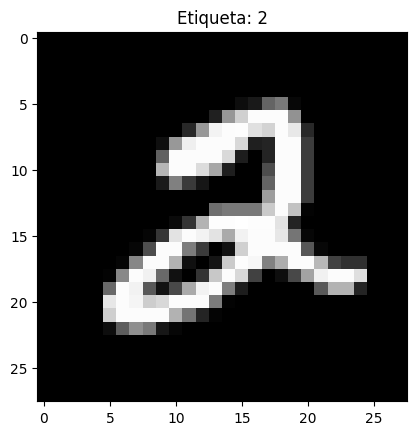

torch.Size([1, 28, 28])


In [ ]:
image, label = train_dataset[3]
plt.imshow(image.permute(1, 2, 0).cpu(), cmap = 'gray')
plt.title(f"Etiqueta: {label}")
plt.show()
print(image.shape)

In [ ]:
class Early_Stop():
  def __init__(self, patience=5, delta=0):
    self.patience = patience
    self.delta = delta
    self.best_val_loss = None
    self.no_val_improvement_times = 0
    self.stop = False

  def check_stop(self, val_loss):
    if self.best_val_loss is None or (val_loss + self.delta) < self.best_val_loss:
      self.best_val_loss = val_loss
      self.no_val_improvement_times = 0
    else:
      self.no_val_improvement_times += 1
      self.stop = self.no_val_improvement_times >= self.patience

In [ ]:
def learning_loop(train_dataloader, val_dataloader, model, epochs, loss_fn, learning_rate, optimizer, validation_freq, early_stop):
  epoch_loss_list = []
  val_loss_list = []

  opt = optimizer(model.parameters(), lr=learning_rate)

  with tqdm(range(epochs), desc="Epoch:") as pbar:
    for epoch in pbar:
      steps_loss_list = []
      for x_true, y_true in train_dataloader:
        y_pred, _ = model(x_true)                           # Forward
        opt.zero_grad()
        loss = loss_fn(y_pred, y_true)
        loss.backward()                                     # Backward
        steps_loss_list.append(loss.clone().detach())
        opt.step()

      train_loss = torch.tensor(steps_loss_list).mean()
      epoch_loss_list.append(train_loss.cpu())
      pbar.set_postfix(loss=f"{train_loss:.4f}")

      if epoch % validation_freq == 0:
        val_step_loss_list = []
        val_correct_answers = 0

        with torch.no_grad():
          for x_val_true, y_val_true in val_dataloader:
            y_val_pred, _ = model(x_val_true)
            loss_val = loss_fn(y_val_pred, y_val_true)
            val_step_loss_list.append(loss_val)

          val_loss = torch.tensor(val_step_loss_list).mean()
          val_loss_list.append(val_loss.cpu())

        early_stop.check_stop(val_loss)
        if early_stop.stop:
          print(f"\nEarly Stop en la época {epoch}.")
          break

  return model, epoch_loss_list, val_loss_list

In [ ]:
def covariance_ellipse(points, num_of_stds=2.0, **kwargs):
  # 1. Find the center of the cluster
    center = np.mean(points, axis=0)

    # 2. Calculate the Covariance Matrix
    cov = np.cov(points, rowvar=False)

    # 3. Get Eigenvalues and Eigenvectors
    eigenvalues, eigenvectors = np.linalg.eigh(cov)

    # Sort them from largest to smallest to find the main axis of the stretch
    order = eigenvalues.argsort()[::-1]
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]

    # 4. Calculate the angle of rotation in degrees (Matplotlib requires degrees)
    angle = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))

    # 5. Calculate the true width and height
    width, height = 2 * num_of_stds * np.sqrt(eigenvalues)

    # Create the perfectly fitted ellipse
    ellipse = Ellipse(xy=center, width=width, height=height, angle=angle, **kwargs)

    return ellipse

## Experimento con sigmoide:

In [ ]:
class Encoder(nn.Module):
    def __init__(self, latent_dims=2, num_classes=6):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 128),
            nn.LeakyReLU(),
            nn.Linear(128, 64),
            nn.LeakyReLU(),
            nn.Linear(64, latent_dims),
            nn.Sigmoid()
        )

        self.classifier = nn.Linear(latent_dims, num_classes)

    def forward(self, x):
        latent_space = self.encoder(x)
        predict = self.classifier(latent_space)
        return predict, latent_space